## Setting the initial simulation parameters


# 6.2 API Tutorial of Gamma Rhythms

## 1. Background

In order to understand the workflow and initial parameter sets provided with this tutorial, we must first briefly describe prior studies on the mechanistic origin of gamma rhythms, including our prior modeling work that led to the creation of the parameter sets you will work with (Lee and Jones, 2013).

Gamma rhythms can encompass a wide band of frequencies from 30-150 Hz. Here, we will focus on the generation of so called low gamma rhythms in the 30-80 Hz range. It has been well established through experiments and computational modeling that these rhythms can emerge in local spiking networks through interactions of excitatory cell and inhibitory cell interactions, with the period of the oscillation set by the time constant of decay of GABAA-mediated inhibitory currents ((Cardin et al., 2009), (Vierling-Claassen et al., 2010), (Buzsáki and Wang, 2012)), a mechanism that has been referred to as pyramidal-interneuronal gamma (PING). In normal regimes, the decay time constant of GABAA-mediated synapses (~25 ms) bounds oscillations to the low gamma frequency band (~40 Hz).

In general, PING rhythms are initiated by "excitation" to the excitatory (E) cells that causes spiking, which in turn synaptically activates a spiking population of inhibitory (I) cells. In turn, these I cells inhibit the E cells, preventing further E cell activity until the E cells can overcome the effects of the inhibition (~25 ms later). The pattern is repeated, creating a gamma frequency oscillation (~40 Hz, 40 spikes/second). This general principle is schematically described in Figure 1 below. The frequency of the rhythm is paced by this time constant of decay of inhibition, which is mediated by strong GABA-A currents, as well as the excitability of the E cells (if the E cells are very excitable, they can fire before the inhibition has completely worn off, and the oscillation will be faster).

<div class="stylefig">
### Figure 1
<!-- was originally at ![](https://raw.githubusercontent.com/jonescompneurolab/hnn-tutorials/master/gamma/images/image19.png) -->
![Schematic illustration showing the PING rhythm mechanism with excitatory pyramidal neurons firing first, followed by inhibitory interneurons, with timing controlled by GABA-A decay, adapted from several figures in the papers of the Background section](https://raw.githubusercontent.com/jonescompneurolab/jones-website/master/images/textbook/content/07_gamma/gamma_fig_01.png)
</div>

In this tutorial, we will explore the generation of PING rhythms in the HNN model. We will provide example parameter files and walk through simulations that generate gamma activity in both Layers 2/3 and Layer 5, as in (Lee and Jones, 2013). This tutorial relies on a different type of exogenous drive to "activate" the local network than the other tutorials. Here, the necessary excitation to generate spiking in the pyramidal neurons that initiates the rhythm (see PING description above) is provided by a continuous train of action potentials with a Poisson distribution that activates post-synaptic excitatory AMPA synapses on the pyramidal neurons. This Poisson drive causes the pyramidal neurons to fire, dependent on the chosen conductance of the AMPA currents. The inhibition in the network is strong enough to overcome the Poisson drive and entrain the network spiking into a gamma frequency rhythm.

Of note, gamma rhythms can be generated by circuit mechanisms other than PING, including subthreshold rhythmic exogenous drive. The publication (Lee and Jones, 2013) examined various mechanisms of generation of gamma activity and described ways to distinguish the mechanisms of generation based on features of current dipole signal. After completing this tutorial, we encourage you to explore alternate mechanisms of gamma generation and to compare to your own gamma data.

<div class="callout callout-warning">
  <table class="callout-table">
    <tr>
      <td class="emoji-cell">
        <svg class="exclamation-icon" viewBox="0 0 16 16" width="20" height="20">
            <path d="M15.35 12.81 9 2.08a1.22 1.22 0 0 0-2 0L.65 12.81a1.14 1.14 0 0 0 1 1.69h12.66a1.14 1.14 0 0 0 1.04-1.69zm-13.66.55L8 2.64l6.31 10.72z"/>
            <path d="M7.32 5.45h1.25V10H7.32z"/>
            <ellipse cx="7.95" cy="11.9" rx=".67" ry=".7"/>
        </svg>
      </td>
      <td class="text-cell">
      Please note that the configuration we use in this Tutorial is for illustrative purposes only. In this network, Layer 2/3 and Layer 5 are not connected to each other, and additionally, Layer 2/3 and Layer 5 pyramidal cells are not connected to other cells of the same time. Therefore, *the network used is not biologically realistic*.
    </td>
      <td class="emoji-cell"> </td>
    </tr>
  </table>
</div>


# 2. Downloading HNN Parameter Set Files

Before we do anything else, we will import the python libraries that we need:


In [1]:
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import matplotlib.pyplot as plt

import hnn_core
# from hnn_core import read_params, jones_2009_model, simulate_dipole
from hnn_core import read_network_configuration, simulate_dipole
try:
    from hnn_core.parallel_backends import MPIBackend
except ImportError:
    from hnn_core.parallel_backends import JoblibBackend
from hnn_core.network import pick_connection
from hnn_core.viz import plot_dipole

Throughout this tutorial, we will be using several different HNN parameter set files. These files are not included in the HNN installation, but instead must be downloaded separately. These four files are located at https://github.com/jonescompneurolab/hnn-data/tree/main/workshops/2025-04-09-HNN-online_workshop/gamma_gui_walkthrough  .

In [2]:
# If you have already downloaded the gamma network files
# to your own directory, then please change this path to 
# point to where you downloaded the files, and you can skip
# the next code cell.
local_gamma_network_files_directory = Path.cwd() / "gamma_network_files"

In [3]:
# Only run this if you have NOT already downloaded the gamma 
# network files, since it will save a copy of the files
Path.mkdir(local_gamma_network_files_directory, exist_ok=True)
data_directory_url = "https://raw.githubusercontent.com/jonescompneurolab/hnn-data/main/workshops/2025-04-09-HNN-online_workshop/gamma_gui_walkthrough/"
files_to_download = [
    "gamma_L5weak_L2weak.json",
    "gamma_L5weak_only.json",
    "gamma_L5ping_L2ping.json",
    "gamma_rhythmic_drive.json",
]
for file_name in files_to_download:
    urlretrieve(
        data_directory_url + file_name, 
        local_gamma_network_files_directory / file_name,
        )


# 3. Setting Initial Run Parameters

Next, let's prepare for our first simulation:

In [ ]:
# Load the gamma network parameter file. 
net = read_network_configuration(local_gamma_network_files_directory / 'gamma_L5weak_L2weak.json')

# --- Settings shared by every simulation in this notebook ---
tstop = 300.0             # ms;
# tmin = 50.0               # ms; omit the initial transient for spectral analysis
tmin = 0.0               # ms; omit the initial transient for spectral analysis
trial_idx = 0             # index of the single trial run in each simulation
scaling_factor = 3000     
freqs = np.arange(10., 100., 1.)   # frequency range (Hz) for spectrogram plots
# net.external_drives['extpois']['dynamics']['tstop'] = tstop


# 4. Load/view Parameters of the Network Structure

We can easily inspect all connections of the network by printing the `Network` attribute for connectivity. This will give us information similar to the GUI list of each connection/drive. 

Note that, since this tutorial is using a special case of the network, Layers 2/3 and 5 are not connected to each other. Additionally, note that there are no active connections between L2/3 pyramidal cells to other L2/3 pyramidal cells, and L5 pyramidal cells are disconnected from each other as well. Note that since drives are considered part of the connectivity of the network, drive connections are also shown by this command.

In [13]:
net.connectivity

[L2_pyramidal -> L2_pyramidal
 cell counts: 100 srcs, 100 targets
 connection probability: 1.0 
 loc: 'proximal'; receptor: 'nmda'
 weight: 0.0; delay: 1.0; lamtha: 3.0threshold: 0.0gain: 1.0
  ,
 L2_pyramidal -> L2_pyramidal
 cell counts: 100 srcs, 100 targets
 connection probability: 1.0 
 loc: 'proximal'; receptor: 'ampa'
 weight: 0.0; delay: 1.0; lamtha: 3.0threshold: 0.0gain: 1.0
  ,
 L5_pyramidal -> L5_pyramidal
 cell counts: 100 srcs, 100 targets
 connection probability: 1.0 
 loc: 'proximal'; receptor: 'nmda'
 weight: 0.0; delay: 1.0; lamtha: 3.0threshold: 0.0gain: 1.0
  ,
 L5_pyramidal -> L5_pyramidal
 cell counts: 100 srcs, 100 targets
 connection probability: 1.0 
 loc: 'proximal'; receptor: 'ampa'
 weight: 0.0; delay: 1.0; lamtha: 3.0threshold: 0.0gain: 1.0
  ,
 L2_basket -> L2_pyramidal
 cell counts: 35 srcs, 100 targets
 connection probability: 1.0 
 loc: 'soma'; receptor: 'gabaa'
 weight: 0.007; delay: 1.0; lamtha: 50.0threshold: 0.0gain: 1.0
  ,
 L2_basket -> L2_pyramid

# 5. Load/view parameters of the external drive

Similarly, we can see the output of all drives easily by printing the corresponding `Network` attribute:

In [14]:
net.external_drives

{'extpois': <External drive 'extpois'
 drive class: poisson
 target location: proximal
 target cell types: ['L2_basket', 'L2_pyramidal', 'L5_basket', 'L5_pyramidal']
 number of drive cells: 270
 cell-specific: True
 dynamic parameters:
 	tstart: 0
 	tstop: 300.0
 	rate_constant: {'L2_basket': 1, 'L2_pyramidal': 140.0, 'L5_basket': 1, 'L5_pyramidal': 40.0}>}

# 6. Run the simulation and visualize the dipole and spectrogram

MPI will run 1 trial(s) sequentially by distributing network neurons over 12 processes.
numprocs=12
[pop-os][[51075,1],5][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[51075,1],5][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[51075,1],5][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[51075,1],8][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[51075,1],1][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[51075,1],5][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote inter

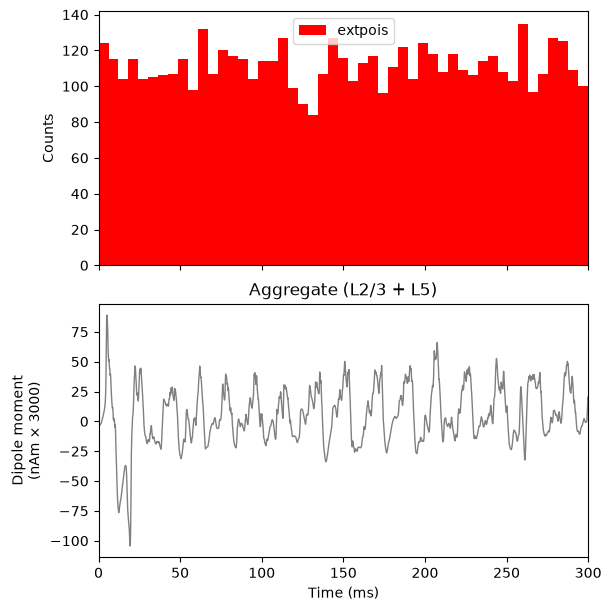

In [15]:
# -----------------------------------------------------------------------
# Run the first simulation and visualize the external input and dipole
# -----------------------------------------------------------------------
with MPIBackend():
    dpl = simulate_dipole(net, tstop=tstop, n_trials=1)[trial_idx]
dpl.scale(scaling_factor)

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(6, 6), constrained_layout=True)

# Top panel: external drive spike-time histogram (the single 'extpois' drive)
net.cell_response.plot_spikes_hist(ax=axes[0], spike_types=['extpois'], show=False)

# Bottom panel: aggregate dipole waveform
plot_dipole(dpl, ax=axes[1], layer='agg', show=False)

plt.show()


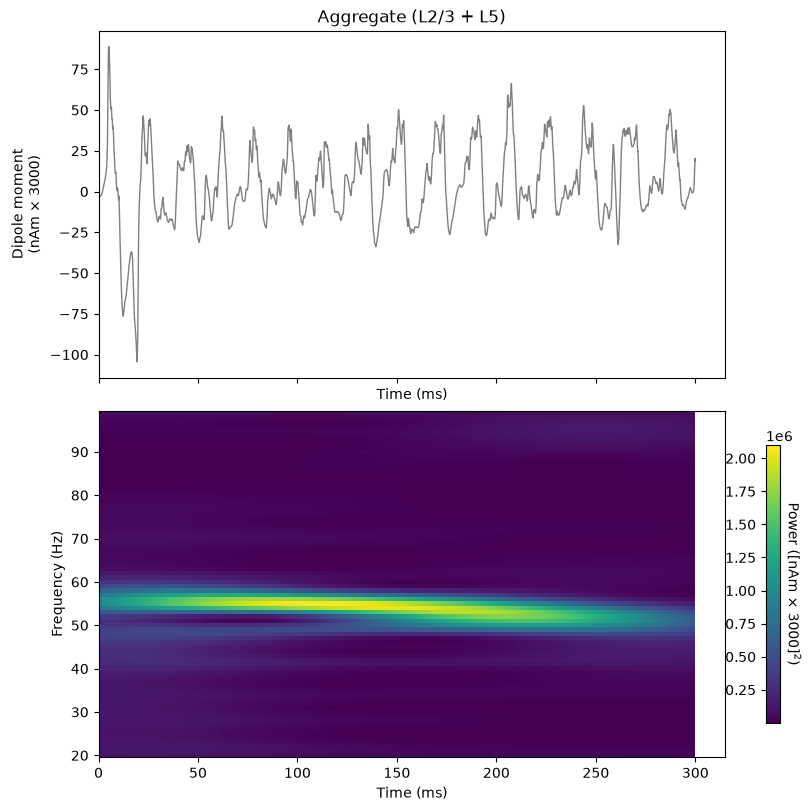

In [ ]:
# -----------------------------------------------------------------------
# Reproduce the GUI's "Dipole Spectrogram" figure: raw dipole waveform on
# top, Morlet time-frequency representation below. We omit the first
# tmin=50 ms transient before any spectral analysis.
# -----------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(8, 8), constrained_layout=True)

dpl.plot(tmin=0, ax=axes[0], layer='agg', show=False)
axes[0].set_title('Aggregate (L2/3 + L5)')

dpl.plot_tfr_morlet(
    freqs, 
    n_cycles=freqs / 2.0, 
    tmin=tmin, 
    layer='agg', 
    ax=axes[1], 
    show=False,
    colormap='viridis'
)

plt.show()

## Calculating power spectral density and viewing spiking activity


In [ ]:
# -----------------------------------------------------------------------
# Spiking activity and layer-resolved power spectral density (PSD)
#
# The raster shows the PING sequence (pyramidal cells fire, then basket
# cells shortly after, then silence until the next cycle). The PSD is
# plotted separately per layer plus the aggregate: L2/3 and L5 have
# slightly different peak frequencies since the layers are disconnected,
# and L5 has larger PSD amplitude since L5 pyramidal cells contribute more
# strongly to the aggregate dipole.
# -----------------------------------------------------------------------

# function to reproduce the GUI's "PSD Layers" visualization template
def plot_psd_by_layer(dpl_to_plot, sim_name, tmin=50., fmin=10, fmax=100):
    """Plot L2/3, L5, and aggregate PSDs of a dipole in 3 stacked panels.

    This is the API equivalent of the GUI's "PSD Layers" visualization
    template: one subplot per layer, each with its own y-axis scale and a
    legend labeled with `sim_name`.
    """
    fig, axes = plt.subplots(3, 1, figsize=(8, 10), constrained_layout=True)
    layer_labels = [('L2', 'Layer 2/3'), ('L5', 'Layer 5'), ('agg', 'Aggregate')]
    for ax, (layer, layer_label) in zip(axes, layer_labels):
        dpl_to_plot.plot_psd(fmin=fmin, fmax=fmax, tmin=tmin, layer=layer,
                              label=f'{sim_name} ({layer_label})', ax=ax, show=False)
        ax.legend()
    plt.show()
    return fig


_ = net.cell_response.plot_spikes_raster(trial_idx=trial_idx)
plt.show()

_ = plot_psd_by_layer(dpl, sim_name='gamma_L5weak_L2weak', tmin=tmin)


## Restricting activity to layer 5


In [ ]:
# -----------------------------------------------------------------------
# Restricting activity to layer 5
#
# Build a fresh network and add the Poisson drive to L5_pyramidal only
# (cell types omitted from weights_ampa get zero drive weight). L2/3 stays
# silent for lack of external input while remaining structurally present.
# This net_l5 / dpls_l5 baseline is reused in every section below.
# -----------------------------------------------------------------------
import os
params_file = op.join(os.getcwd(), 'gamma_L5weak_only.json')

#params = read_params(params_file)
#net_l5 = jones_2009_model(params, add_drives_from_params=True) 

net_l5 = jones_2009_model(params)
net_l5.add_poisson_drive(
    'poisson', rate_constant={'L5_pyramidal': 40.0},
    weights_ampa={'L5_pyramidal': 0.0075}, location='proximal',
    synaptic_delays={'L5_pyramidal': 1.0}, event_seed=1349)

with JoblibBackend(n_jobs=n_jobs):
    dpls_l5 = simulate_dipole(net_l5, tstop=tstop, n_trials=1)
dpls_l5 = [d.scale(scaling_factor) for d in dpls_l5]

_ = net_l5.cell_response.plot_spikes_raster(trial_idx=trial_idx)
plt.show()


## Increasing cell excitability via a weak tonic input


In [ ]:
# -----------------------------------------------------------------------
# Increasing cell excitability via a weak tonic input
#
# Add a tonic bias (i.e., a constant applied current) at 2 nA
# directly to L5 pyramidal cells and compare
# against the net_l5 baseline. Counter-intuitively, even though single-
# cell excitability goes up, the oscillation frequency tends to go down
# slightly: more pyramidal cells fire, recruiting stronger inhibitory
# feedback that takes longer to decay.
# -----------------------------------------------------------------------
net_tonic_weak = jones_2009_model(params)
net_tonic_weak.add_poisson_drive(
    'poisson', rate_constant={'L5_pyramidal': 40.0},
    weights_ampa={'L5_pyramidal': 0.0075}, location='proximal',
    synaptic_delays={'L5_pyramidal': 1.0}, event_seed=1349)
net_tonic_weak.add_tonic_bias(cell_type='L5_pyramidal', amplitude=2.)

with JoblibBackend(n_jobs=n_jobs):
    dpls_tonic_weak = simulate_dipole(net_tonic_weak, tstop=tstop, n_trials=1)
dpls_tonic_weak = [d.scale(scaling_factor) for d in dpls_tonic_weak]

_ = dpls_tonic_weak[trial_idx].plot(tmin=tmin)
plt.show()

_ = net_tonic_weak.cell_response.plot_spikes_raster(trial_idx=trial_idx)
plt.show()

_ = plot_psd_by_layer(dpls_tonic_weak[trial_idx],
                       sim_name='gamma_L5weak_only_tonic1', tmin=tmin)


## Increasing tonic input


In [ ]:
# -----------------------------------------------------------------------
# Increasing tonic input further
#
# Push the tonic drive to L5 pyramidal cells up to 6 nA and see whether
# the frequency-lowering trend continues.
# -----------------------------------------------------------------------
net_tonic_strong = jones_2009_model(params)
net_tonic_strong.add_poisson_drive(
    'poisson', rate_constant={'L5_pyramidal': 40.0},
    weights_ampa={'L5_pyramidal': 0.0075}, location='proximal',
    synaptic_delays={'L5_pyramidal': 1.0}, event_seed=1349)
net_tonic_strong.add_tonic_bias(cell_type='L5_pyramidal', amplitude=6.)

with JoblibBackend(n_jobs=n_jobs):
    dpls_tonic_strong = simulate_dipole(net_tonic_strong, tstop=tstop, n_trials=1)
dpls_tonic_strong = [d.scale(scaling_factor) for d in dpls_tonic_strong]

_ = net_tonic_strong.cell_response.plot_spikes_raster(trial_idx=trial_idx)
plt.show()

_ = dpls_tonic_strong[trial_idx].plot(tmin=tmin)
plt.show()

# Compare against the previous cell's PSDs to see the effect of increasing
# the tonic drive from 2 to 6 nA.
_ = plot_psd_by_layer(dpls_tonic_strong[trial_idx],
                       sim_name='gamma_L5weak_only_tonic2', tmin=tmin)


## Weakening the excitatory connections


In [ ]:
# -----------------------------------------------------------------------
# Weakening the excitatory L5 Pyramidal -> L5 Basket connection
#
# Change connectivity: reduce the excitatory (AMPA)
# synaptic weight from L5 pyramidal cells onto L5 basket cells to
# one-tenth of its original value, keeping the 6 nA tonic drive from the
# previous section. Because excitation
# onto basket cells is weaker, they take longer to reach threshold,
# delaying inhibitory feedback and slowing the oscillation.
# -----------------------------------------------------------------------
net_weak_conn = jones_2009_model(params)
net_weak_conn.add_poisson_drive(
    'poisson', rate_constant={'L5_pyramidal': 40.0},
    weights_ampa={'L5_pyramidal': 0.0075}, location='proximal',
    synaptic_delays={'L5_pyramidal': 1.0}, event_seed=1349)
net_weak_conn.add_tonic_bias(cell_type='L5_pyramidal', amplitude=6.)

conn_indices = pick_connection(net_weak_conn, src_gids='L5_pyramidal',
                                target_gids='L5_basket', receptor='ampa')
for idx in conn_indices:
    print('original weight:', net_weak_conn.connectivity[idx]['weight'])
    net_weak_conn.connectivity[idx]['weight'] *= 0.1
    print('new weight:', net_weak_conn.connectivity[idx]['weight'])

with JoblibBackend(n_jobs=n_jobs):
    dpls_weak_conn = simulate_dipole(net_weak_conn, tstop=tstop, n_trials=1)
dpls_weak_conn = [d.scale(scaling_factor) for d in dpls_weak_conn]

_ = net_weak_conn.cell_response.plot_spikes_raster(trial_idx=trial_idx)
plt.show()

_ = dpls_weak_conn[trial_idx].plot(tmin=tmin)
plt.show()

_ = plot_psd_by_layer(dpls_weak_conn[trial_idx],
                       sim_name='gamma_L5weak_only_tonic3', tmin=tmin)


## Removing basket cell self-inhibition


In [ ]:
# -----------------------------------------------------------------------
# Removing basket-cell self-inhibition
#
# Back to the unmodified net_l5 configuration (no tonic drive, original
# connectivity): set the L5 Basket -> L5 Basket (GABA-A) synaptic weight
# to zero, so basket cells no longer inhibit one another. Without this
# self-inhibition, interneurons lose their synchrony and fire more
# irregularly, so inhibition arriving at pyramidal cells is smeared out in
# time rather than delivered as one coordinated pulse. The gamma rhythm
# persists but becomes less coherent.
# -----------------------------------------------------------------------
net_no_bb = jones_2009_model(params)
net_no_bb.add_poisson_drive(
    'poisson', rate_constant={'L5_pyramidal': 40.0},
    weights_ampa={'L5_pyramidal': 0.0075}, location='proximal',
    synaptic_delays={'L5_pyramidal': 1.0}, event_seed=1349)

conn_indices = pick_connection(net_no_bb, src_gids='L5_basket',
                                target_gids='L5_basket', receptor='gabaa')
for idx in conn_indices:
    print('original weight:', net_no_bb.connectivity[idx]['weight'])
    net_no_bb.connectivity[idx]['weight'] = 0.

with JoblibBackend(n_jobs=n_jobs):
    dpls_no_bb = simulate_dipole(net_no_bb, tstop=tstop, n_trials=1)
dpls_no_bb = [d.scale(scaling_factor) for d in dpls_no_bb]

_ = net_no_bb.cell_response.plot_spikes_raster(trial_idx=trial_idx)
plt.show()

fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(6, 6),
                          constrained_layout=True)
dpls_no_bb[trial_idx].plot(tmin=tmin, ax=axes[0], show=False)
dpls_no_bb[trial_idx].plot_tfr_morlet(freqs, n_cycles=7, tmin=tmin, ax=axes[1], show=False)
axes[1].set_xlim(tmin, tstop)
plt.show()

_ = plot_psd_by_layer(dpls_no_bb[trial_idx],
                       sim_name='gamma_L5weak_only_noinhibition', tmin=tmin)


## Reducing the GABAA decay time


In [ ]:
# -----------------------------------------------------------------------
# Reducing the GABA-A decay time constant
#
# Back to the unmodified net_l5 configuration once more: shorten the
# GABA-A decay time constant (tau2) of synapses onto L5 pyramidal cells
# from the default 5 ms to 2 ms. Faster-decaying inhibition lets
# pyramidal cells recover and fire again sooner, which increases
# the oscillation frequency.
# -----------------------------------------------------------------------
net_gabaa = jones_2009_model(params)
net_gabaa.add_poisson_drive(
    'poisson', rate_constant={'L5_pyramidal': 40.0},
    weights_ampa={'L5_pyramidal': 0.0075}, location='proximal',
    synaptic_delays={'L5_pyramidal': 1.0}, event_seed=1349)

print('original GABA-A tau2:',
      net_gabaa.cell_types['L5_pyramidal']['cell_object'].synapses['gabaa']['tau2'], 'ms')
net_gabaa.cell_types['L5_pyramidal']['cell_object'].synapses['gabaa']['tau2'] = 2

with JoblibBackend(n_jobs=n_jobs):
    dpls_gabaa = simulate_dipole(net_gabaa, tstop=tstop, n_trials=1)
dpls_gabaa = [d.scale(scaling_factor) for d in dpls_gabaa]

_ = net_gabaa.cell_response.plot_spikes_raster(trial_idx=trial_idx)
plt.show()

fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(6, 6),
                          constrained_layout=True)
dpls_gabaa[trial_idx].plot(tmin=tmin, ax=axes[0], show=False)
dpls_gabaa[trial_idx].plot_tfr_morlet(freqs, n_cycles=7, tmin=tmin, ax=axes[1], show=False)
axes[1].set_xlim(tmin, tstop)
plt.show()

_ = plot_psd_by_layer(dpls_gabaa[trial_idx],
                       sim_name='gamma_L5weak_only_shorter_decay_gabaa', tmin=tmin)


### Strong PING still missing

## References

Buzsáki, György, and Xiao-Jing Wang. 2012. “Mechanisms of Gamma Oscillations.” Annual Review of Neuroscience 35 (1): 203–25. https://doi.org/10.1146/annurev-neuro-062111-150444.

Cardin, Jessica A., Marie Carlén, Konstantinos Meletis, Ulf Knoblich, Feng Zhang, Karl Deisseroth, Li-Huei Tsai, and Christopher I. Moore. 2009. “Driving Fast-Spiking Cells Induces Gamma Rhythm and Controls Sensory Responses.” Nature 459 (7247): 663–67. https://doi.org/10.1038/nature08002.

Lee, Shane, and Stephanie R. Jones. 2013. “Distinguishing Mechanisms of Gamma Frequency Oscillations in Human Current Source Signals Using a Computational Model of a Laminar Neocortical Network.” Frontiers in Human Neuroscience 7 (December). https://doi.org/10.3389/fnhum.2013.00869.

Vierling-Claassen, Dorea, Jessica Cardin, Christopher I. Moore, and Stephanie R. Jones. 2010. “Computational Modeling of Distinct Neocortical Oscillations Driven by Cell-Type Selective Optogenetic Drive: Separable Resonant Circuits Controlled by Low-Threshold Spiking and Fast-Spiking Interneurons.” Frontiers in Human Neuroscience 4 (November). https://doi.org/10.3389/fnhum.2010.00198. 